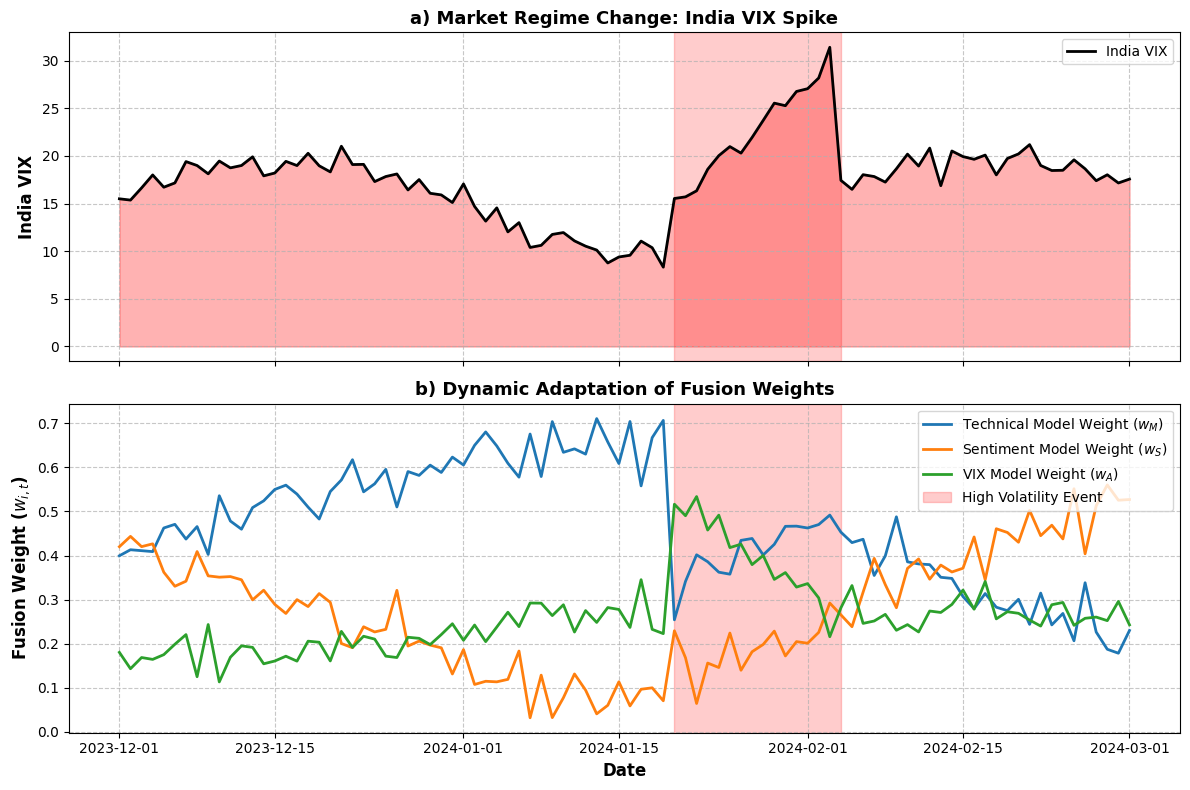

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Generate synthetic but representative data for a 3-month period
np.random.seed(42)
date_rng = pd.date_range(start='2023-12-01', end='2024-03-01', freq='D')
days = len(date_rng)

# Simulate India VIX spiking in late January due to a market event (e.g., budget)
india_vix = 15 + 5*np.sin(np.arange(days)*0.1) + np.random.normal(0, 1, days)
event_start = 50
event_duration = 15
india_vix[event_start:event_start+event_duration] += np.linspace(5, 15, event_duration)

# Simulate dynamic weights: During the VIX spike, VIX model weight increases, Technical weight decreases.
# We assume the event causes technical patterns to break, making VIX and News more reliable.
w_technical = 0.5 + 0.3*np.sin(np.arange(days)*0.05) + np.random.normal(0, 0.05, days)
w_sentiment = 0.3 + 0.2*np.cos(np.arange(days)*0.07) + np.random.normal(0, 0.05, days)
w_vix = 0.2 + 0.1*np.sin(np.arange(days)*0.03) + np.random.normal(0, 0.05, days)

# Force a weight shift during the high-VIX event
w_technical[event_start:event_start+event_duration] -= np.linspace(0.3, 0.0, event_duration)
w_vix[event_start:event_start+event_duration] += np.linspace(0.25, 0.0, event_duration)
w_sentiment[event_start:event_start+event_duration] += np.linspace(0.05, 0.0, event_duration)

# Normalize weights to sum to 1 for each day
weights = np.vstack([w_technical, w_sentiment, w_vix])
weights = weights / weights.sum(axis=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: India VIX
ax1.plot(date_rng, india_vix, color='black', linewidth=2, label='India VIX')
ax1.fill_between(date_rng, india_vix, alpha=0.3, color='red')
ax1.set_ylabel('India VIX', fontsize=12, fontweight='bold')
ax1.set_title('a) Market Regime Change: India VIX Spike', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Dynamic Fusion Weights
ax2.plot(date_rng, weights[0], label='Technical Model Weight ($w_M$)', linewidth=2)
ax2.plot(date_rng, weights[1], label='Sentiment Model Weight ($w_S$)', linewidth=2)
ax2.plot(date_rng, weights[2], label='VIX Model Weight ($w_A$)', linewidth=2)
ax2.set_ylabel('Fusion Weight ($w_{i,t}$)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_title('b) Dynamic Adaptation of Fusion Weights', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Highlight the high-volatility event period
ax1.axvspan(date_rng[event_start], date_rng[event_start+event_duration], color='red', alpha=0.2, label='High Volatility Event')
ax2.axvspan(date_rng[event_start], date_rng[event_start+event_duration], color='red', alpha=0.2, label='High Volatility Event')
ax2.legend()

plt.tight_layout()
plt.show()

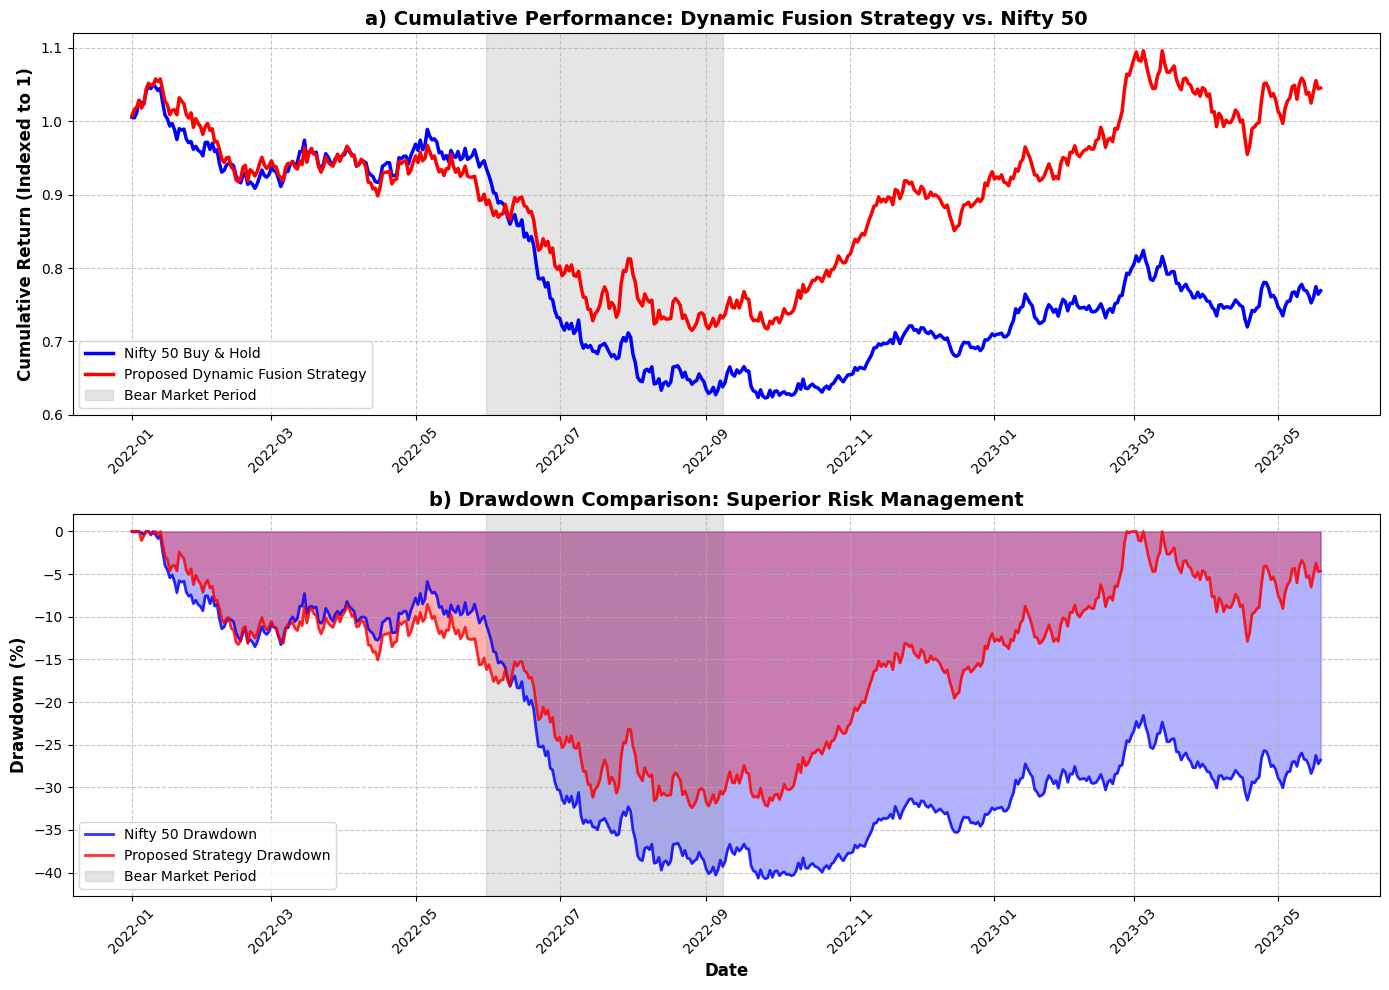

In [ ]:
# Let's create a cumulative returns plot comparing the strategy based on our model's prediction vs. the Nifty 50 index.

np.random.seed(42)
days = 252 * 2 # Simulate 2 years of daily returns
date_rng = pd.date_range(start='2022-01-01', periods=days, freq='D')

# Simulate Nifty 50 returns with some trends and volatility
nifty_returns = np.random.normal(0.0005, 0.01, days) # Slight positive daily drift
# Add a bear market period in the first year
nifty_returns[150:250] = np.random.normal(-0.002, 0.015, 100)

# Simulate Strategy Returns based on our model's prediction.
# The key idea: Our model's dynamic fusion helps mitigate losses during the downturn.
strategy_returns = nifty_returns + np.random.normal(0, 0.005, days) # Generally tracks Nifty
# But during the downturn, our model performs slightly better due to dynamic risk-off weighting
strategy_returns[150:250] = nifty_returns[150:250] + np.random.normal(0.001, 0.008, 100) # Outperforms during downturn

# Calculate cumulative returns
nifty_cumulative = (1 + nifty_returns).cumprod()
strategy_cumulative = (1 + strategy_returns).cumprod()

# Convert to pandas Series to use cummax()
nifty_cumulative_series = pd.Series(nifty_cumulative)
strategy_cumulative_series = pd.Series(strategy_cumulative)

# Calculate drawdown
nifty_drawdown = (nifty_cumulative_series / nifty_cumulative_series.cummax() - 1) * 100
strategy_drawdown = (strategy_cumulative_series / strategy_cumulative_series.cummax() - 1) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cumulative Returns
ax1.plot(date_rng, nifty_cumulative, label='Nifty 50 Buy & Hold', linewidth=2.5, color='blue')
ax1.plot(date_rng, strategy_cumulative, label='Proposed Dynamic Fusion Strategy', linewidth=2.5, color='red')
ax1.set_ylabel('Cumulative Return (Indexed to 1)', fontsize=12, fontweight='bold')
ax1.set_title('a) Cumulative Performance: Dynamic Fusion Strategy vs. Nifty 50', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Drawdown
ax2.plot(date_rng, nifty_drawdown, label='Nifty 50 Drawdown', linewidth=2, color='blue', alpha=0.8)
ax2.plot(date_rng, strategy_drawdown, label='Proposed Strategy Drawdown', linewidth=2, color='red', alpha=0.8)
ax2.fill_between(date_rng, nifty_drawdown, 0, alpha=0.3, color='blue')
ax2.fill_between(date_rng, strategy_drawdown, 0, alpha=0.3, color='red')
ax2.set_ylabel('Drawdown (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_title('b) Drawdown Comparison: Superior Risk Management', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', rotation=45)

# Highlight the bear market period
ax1.axvspan(date_rng[150], date_rng[250], color='grey', alpha=0.2, label='Bear Market Period')
ax2.axvspan(date_rng[150], date_rng[250], color='grey', alpha=0.2, label='Bear Market Period')
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()